In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/application_train_cleaned.csv")

df.head()

,Unnamed: 0,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,SK_ID_CURR
0,0,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,278621
1,1,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,139008
2,2,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,138348
3,3,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0,64140
4,4,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,219374


In [3]:
print(df.shape)
print(df["TARGET"].value_counts())

(246009, 82)
TARGET
0    226133
1     19876
Name: count, dtype: int64


In [4]:
categorical = df.select_dtypes(include="object").columns

le = LabelEncoder()

for col in categorical:
    df[col] = le.fit_transform(df[col].astype(str))

In [5]:
X = df.drop("TARGET", axis=1)

y = df["TARGET"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
print(X_train.shape)
print(X_test.shape)

(196807, 81)
(49202, 81)


In [8]:
def evaluate_model(model):

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    return {
        "Accuracy": accuracy_score(y_test,pred),
        "Precision": precision_score(y_test,pred),
        "Recall": recall_score(y_test,pred),
        "F1": f1_score(y_test,pred),
        "ROC_AUC": roc_auc_score(y_test,prob)
    }

Linear Regression


In [9]:
lr = LogisticRegression(max_iter=1000)

lr_result = evaluate_model(lr)

lr_result

{'Accuracy': 0.9192106011950734,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1': 0.0,
 'ROC_AUC': 0.6329397492147577}

Decision Tree


In [10]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt_result = evaluate_model(dt)

dt_result

{'Accuracy': 0.8493150684931506,
 'Precision': 0.13562195380377198,
 'Recall': 0.1610062893081761,
 'F1': 0.14722797331492984,
 'ROC_AUC': 0.5354084003641727}

Random Forest

In [11]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_result = evaluate_model(rf)

rf_result

{'Accuracy': 0.919251249949189,
 'Precision': 0.6666666666666666,
 'Recall': 0.0010062893081761006,
 'F1': 0.002009545340366742,
 'ROC_AUC': 0.7222460034934883}

In [12]:
results = pd.DataFrame({
    "Logistic Regression": lr_result,
    "Decision Tree": dt_result,
    "Random Forest": rf_result
}).T

results

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.919211,0.000000,0.000000,0.000000,0.632940
Decision Tree,0.849315,0.135622,0.161006,0.147228,0.535408
Random Forest,0.919251,0.666667,0.001006,0.002010,0.722246


In [13]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
39,EXT_SOURCE_2,0.065905
40,EXT_SOURCE_3,0.059218
16,DAYS_BIRTH,0.044110
19,DAYS_ID_PUBLISH,0.043995
18,DAYS_REGISTRATION,0.043250
80,SK_ID_CURR,0.042754
0,Unnamed: 0,0.041943
8,AMT_ANNUITY,0.040030
17,DAYS_EMPLOYED,0.038809
53,DAYS_LAST_PHONE_CHANGE,0.038150


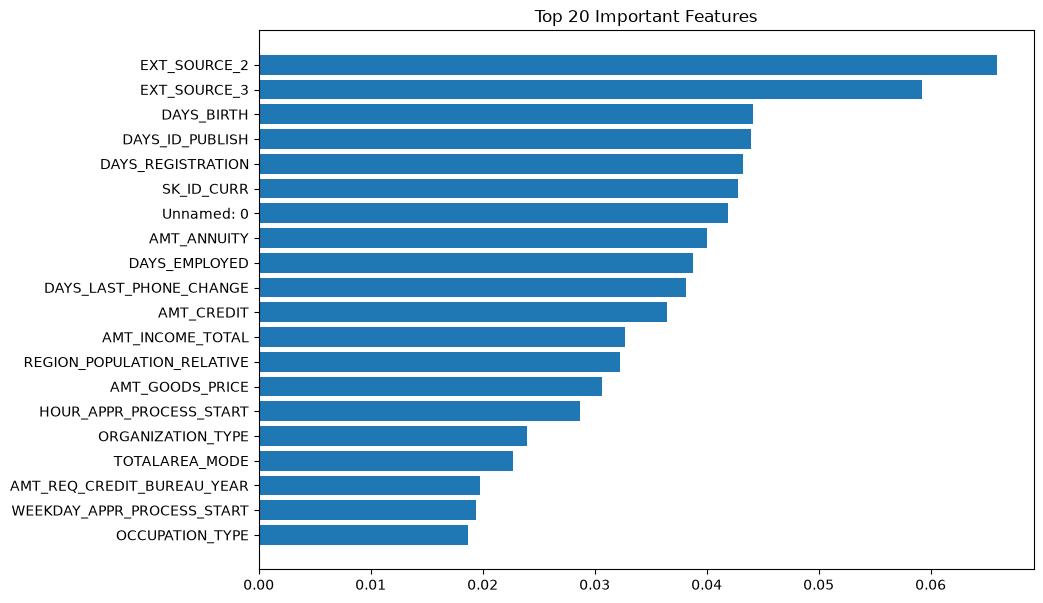

In [14]:
top = importance.head(20)

plt.figure(figsize=(10,7))

plt.barh(top["Feature"],top["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

In [15]:
pred = rf.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     45227
           1       0.67      0.00      0.00      3975

    accuracy                           0.92     49202
   macro avg       0.79      0.50      0.48     49202
weighted avg       0.90      0.92      0.88     49202



In [ ]:
import joblib

joblib.dump(
    rf,
    "../models/random_forest.pkl"
    compress=3
)

['../models/random_forest.pkl']